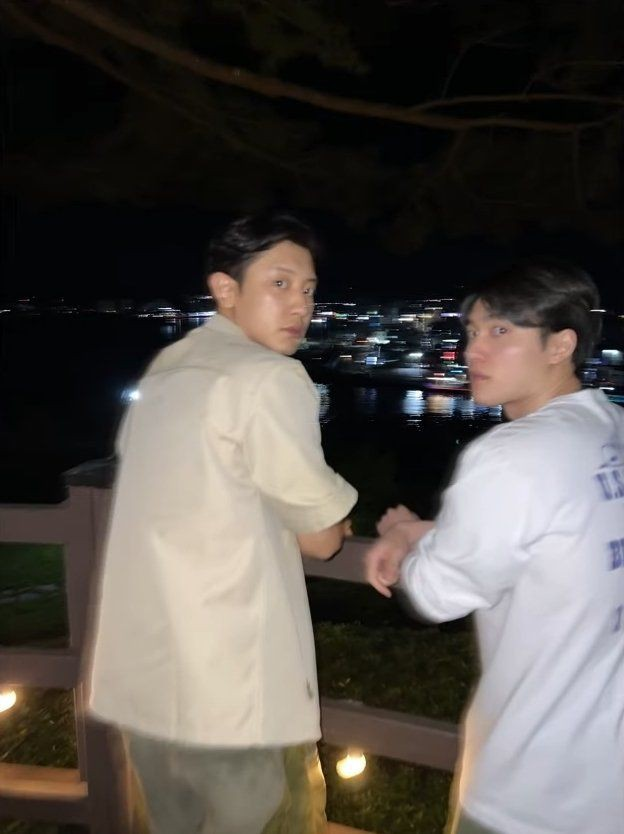

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Membaca gambar
image = cv2.imread('/content/cydo blur.jpeg')

# Menampilkan hasil
cv2_imshow(image)

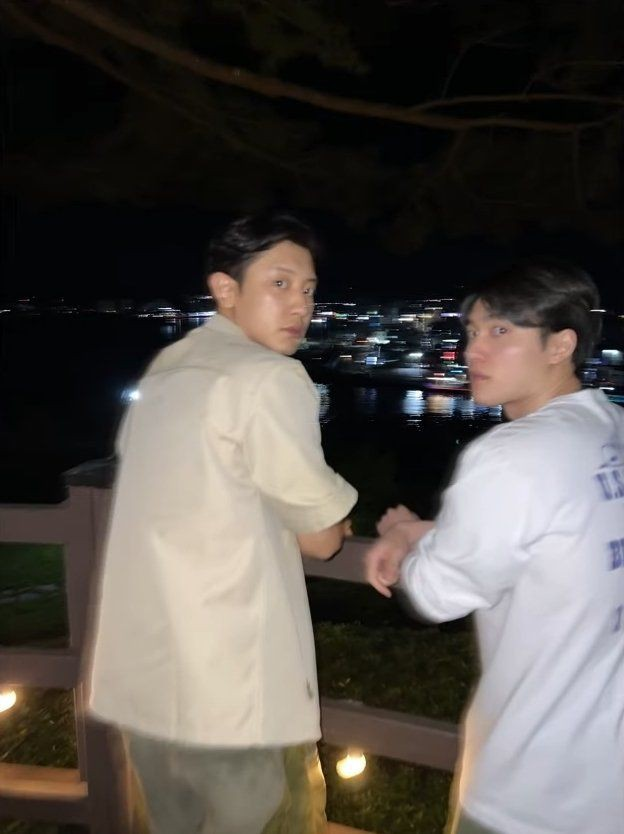

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Membaca gambar
# image = cv2.imread('/content/cydo blur.jpeg', cv2.IMREAD_GRAYSCALE)

# Normalisasi ke rentang [0, 255]
image_normalized = cv2.normalize(image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

# Menampilkan hasil
cv2_imshow(image_normalized)

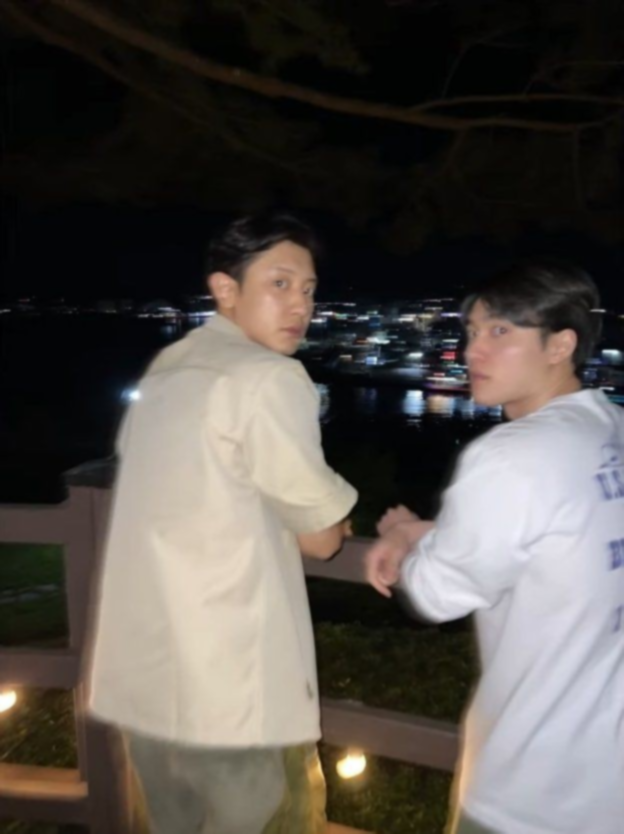

In [ ]:
# Menerapkan Gaussian Blur untuk mengurangi noise
gaussian_blurred = cv2.GaussianBlur(image_normalized, (5, 5), 1.0)
cv2_imshow(gaussian_blurred)


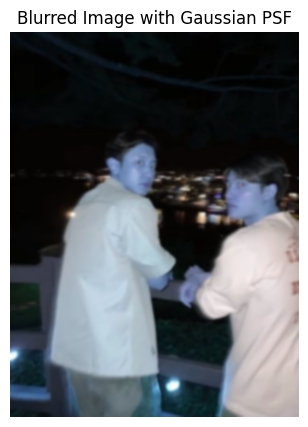

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def gaussian_psf(size, sigma):
    """
    Create a Gaussian PSF kernel.

    Args:
        size (int): Size of the PSF kernel (odd number).
        sigma (float): Standard deviation of the Gaussian.

    Returns:
        np.ndarray: Gaussian PSF kernel.
    """
    kernel = np.zeros((size, size))
    center = size // 2
    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center
            kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

# Load an example image (replace 'example_image.jpg' with your image file)
# image = cv2.imread('example_image.jpg', cv2.IMREAD_GRAYSCALE)

# Define PSF parameters
psf_size = 11  # Adjust according to your desired PSF size
psf_sigma = 2  # Adjust according to your desired Gaussian sigma

# Create Gaussian PSF
psf = gaussian_psf(psf_size, psf_sigma)

# Apply PSF to the image
blurred_image = cv2.filter2D(gaussian_blurred, -1, psf)
cv2.imwrite('blurred_image.jpg', blurred_image)

# Display the original and blurred images
plt.figure(figsize=(10, 5))

# plt.subplot(1, 2, 1)
# plt.title('IDCT Image')
# plt.imshow(idct_image, cmap='gray')
# plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Blurred Image with Gaussian PSF')
plt.imshow(blurred_image, cmap='gray')
plt.axis('off')

plt.show()



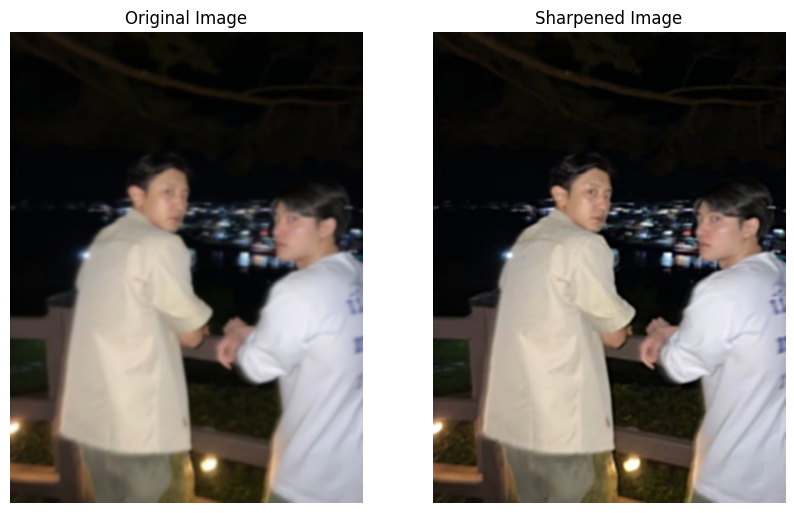

PSNR: 36.85
SSIM: 0.9718


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

def unsharp_mask(image, sigma=1.0, strength=1.5):
    # Menerapkan filter Gaussian untuk penghalusan
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)

    # Membuat mask
    mask = cv2.addWeighted(image, 1 + strength, blurred, -strength, 0)

    return mask

# Mengganti path dengan path file gambar yang ingin diolah
image_path = "/content/blurred_image.jpg"

# Membaca gambar
image = cv2.imread(image_path)

# Memastikan gambar berhasil terbaca
if image is not None:
    # Memanggil fungsi untuk mempertajam gambar menggunakan Unsharp Mask
    sharpened_image = unsharp_mask(image, sigma=2.0, strength=2.0)

    # Mengonversi gambar dari BGR ke RGB untuk menampilkan dengan benar menggunakan matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    sharpened_image_rgb = cv2.cvtColor(sharpened_image, cv2.COLOR_BGR2RGB)

    # Menampilkan gambar asli
    plt.figure(figsize=(10, 10))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(image_rgb)
    plt.axis('off')

    # Menampilkan gambar yang telah dipertajam
    plt.subplot(1, 2, 2)
    plt.title('Sharpened Image')
    plt.imshow(sharpened_image_rgb)
    plt.axis('off')

    plt.show()

    # Evaluasi kualitas gambar
    image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    sharpened_image_gray = cv2.cvtColor(sharpened_image, cv2.COLOR_BGR2GRAY)

    psnr_value = compare_psnr(image_gray, sharpened_image_gray)
    ssim_value = compare_ssim(image_gray, sharpened_image_gray)

    print(f"PSNR: {psnr_value:.2f}")
    print(f"SSIM: {ssim_value:.4f}")
else:
    print("Failed to load the image.")

Unsharp Masking: PSNR = 29.34, SSIM = 0.9217
Unsharp Masking: PSNR = 29.34, SSIM = 0.9217


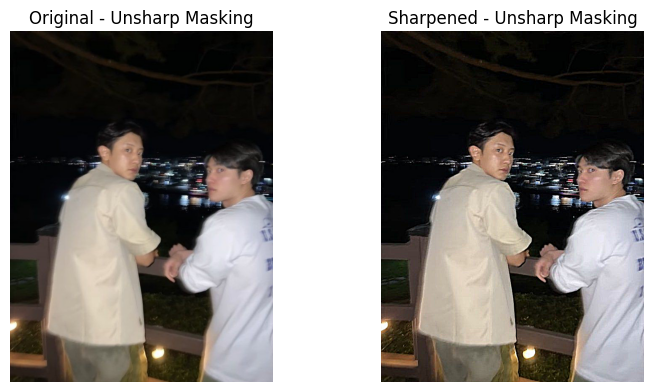

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

# Fungsi untuk mempertajam gambar menggunakan Unsharp Mask
def unsharp_mask(image, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    mask = cv2.addWeighted(image, 1 + strength, blurred, -strength, 0)
    return mask

# Fungsi untuk pra-pemrosesan gambar (misalnya denoising)
def preprocess_image(image):
    denoised = cv2.fastNlMeansDenoisingColored(image, None, 20, 20, 7, 21)
    return denoised

# Path file gambar yang ingin diolah
image_paths = ["cy blur.jpg"]

# Model/metode yang akan digunakan
methods = ["Unsharp Masking", "Unsharp Masking", "Preprocessing + Unsharp Masking", "Preprocessing + Unsharp Masking"]

# Parameter sigma dan strength untuk Unsharp Masking
sigmas = [2.0, 2.0, 2.0, 2.0]
strengths = [2.0, 2.0, 2.0, 1.5]

# Inisialisasi list untuk menyimpan nilai PSNR dan SSIM
psnr_values = []
ssim_values = []

# Mengatur ukuran plot
plt.figure(figsize=(15, 15))

# Loop melalui setiap gambar dan model/metode
for i, (image_path, method, sigma, strength) in enumerate(zip(image_paths, methods, sigmas, strengths)):
    # Membaca gambar
    image = cv2.imread(image_path)

    # Memastikan gambar berhasil terbaca
    if image is not None:
        # Pra-pemrosesan gambar jika diperlukan
        if "Preprocessing" in method:
            image = preprocess_image(image)

        # Memanggil fungsi untuk mempertajam gambar menggunakan Unsharp Masking
        sharpened_image = unsharp_mask(image, sigma=sigma, strength=strength)

        # Mengonversi gambar dari BGR ke RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        sharpened_image_rgb = cv2.cvtColor(sharpened_image, cv2.COLOR_BGR2RGB)

        # Menampilkan gambar asli
        plt.subplot(4, 4, i*2+1)
        plt.imshow(image_rgb)
        plt.title(f'Original - {method}')
        plt.axis('off')

        # Menampilkan gambar yang telah dipertajam
        plt.subplot(4, 4, i*2+2)
        plt.imshow(sharpened_image_rgb)
        plt.title(f'Sharpened - {method}')
        plt.axis('off')

        # Evaluasi kualitas gambar
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        sharpened_image_gray = cv2.cvtColor(sharpened_image, cv2.COLOR_BGR2GRAY)

        psnr_value = compare_psnr(image_gray, sharpened_image_gray)
        ssim_value = compare_ssim(image_gray, sharpened_image_gray)

        psnr_values.append(psnr_value)
        ssim_values.append(ssim_value)

        print(f"{method}: PSNR = {psnr_value:.2f}, SSIM = {ssim_value:.4f}")

# Menampilkan nilai PSNR dan SSIM
for i, (method, psnr, ssim) in enumerate(zip(methods, psnr_values, ssim_values)):
    print(f"{method}: PSNR = {psnr:.2f}, SSIM = {ssim:.4f}")

plt.tight_layout()
plt.show()
